In [17]:
import pickle
# import boris_extraction as boris
# import multirecording_spikeanalysis as spike
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import sem
from itertools import combinations
def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))

In [18]:
behavior_dicts = unpickle_this('behavior_dicts.pkl')


In [19]:
event_info = {}
sniff_itis = []
j = 0
total_sniffs = 0
for behavior_dict in behavior_dicts:
    event_dict_keys = behavior_dict.keys()
    for event, events in behavior_dict.items():
        no_events = events.shape[0]
        sniff_length = 0
        for i in range(len(events)):
            sniff_length_temp = events[i][1] - events[i][0]
            sniff_length = sniff_length + sniff_length_temp
            total_sniffs = total_sniffs + 1
            try:
                sniff_iti = events[i+1][0] - events[i][1]
                sniff_itis.append(sniff_iti)
            except IndexError:
                pass
        total_sniff_time = sniff_length/1000
        try:
            avg_event = sniff_length/no_events/1000
        except ZeroDivisionError:
            avg_event = 0
        if j in event_info.keys():
            dict_event = event_info[j]
            dict_event[event] =  {'no_events': no_events, 'avg event': avg_event, 'total time': total_sniff_time}
            event_info[j] =  dict_event
        else:
            event_info[j] = {event: {'no_events': no_events, 'avg event': avg_event,'total time': total_sniff_time }}
    j += 1
sniff_itis = np.array(sniff_itis)/1000
sniff_itis 
overlapping_sniffs = 0 
for i in range(len(sniff_itis)):
    if sniff_itis[i] < 1:
        overlapping_sniffs = overlapping_sniffs + 1
print(overlapping_sniffs) # was 54 with old thresholding for less than 2, 142 for 5
print(total_sniffs) # out of 524, after fixing 83 for 5 
# out of 465

0
1257


In [20]:
ephy_beh_dict = [item for i, item in enumerate(behavior_dicts) if i != 2]

print(len(ephy_beh_dict))

8


In [23]:
behavior_dicts

[{'cup 1': array([[2083533., 2094567.],
         [2203567., 2204700.],
         [2350067., 2352100.],
         [2421167., 2427700.],
         [2497467., 2498300.]]),
  'cup 2': array([[2039333., 2042067.],
         [2285467., 2286867.],
         [2412933., 2414200.],
         [2500733., 2501233.]]),
  'cup 3': array([[1957367., 1968900.],
         [1970567., 1984500.],
         [1988567., 1997400.],
         [2001000., 2006067.],
         [2044433., 2055800.],
         [2058633., 2071733.],
         [2074167., 2080367.],
         [2117033., 2121867.],
         [2128733., 2141733.],
         [2147233., 2149600.],
         [2207200., 2213967.],
         [2219600., 2238933.],
         [2240233., 2250433.],
         [2289733., 2318667.],
         [2392400., 2397367.],
         [2461400., 2469433.],
         [2503933., 2513667.],
         [2520533., 2521533.]]),
  'cup 4': array([[2106433., 2107133.],
         [2152367., 2154700.],
         [2198533., 2200233.],
         [2441900., 2445733.

In [24]:
event_info = {}
sniff_itis = []
j = 0
total_sniffs = 0
subjects = ['p3d1_1_1', 'p3d1_1_2', 'p3d2_1_1', 'p3d2_1_2', 'p3d2_1_4', 'p3d3_1_1', 'p3d3_1_2', 'p3d3_1_4']
for behavior_dict in ephy_beh_dict:
    event_dict_keys = behavior_dict.keys()
    subject = subjects[j]
    for event, events in behavior_dict.items():
        no_events = events.shape[0]
        sniff_length = 0
        for i in range(len(events)):
            sniff_length_temp = events[i][1] - events[i][0]
            sniff_length = sniff_length + sniff_length_temp
            total_sniffs = total_sniffs + 1
            try:
                sniff_iti = events[i+1][0] - events[i][1]
                sniff_itis.append(sniff_iti)
            except IndexError:
                pass
        total_sniff_time = sniff_length/1000
        try:
            avg_event = sniff_length/no_events/1000
        except ZeroDivisionError:
            avg_event = 0
        if subject in event_info.keys():
            dict_event = event_info[subject]
            dict_event[event] =  {'no_events': no_events, 'avg event': avg_event, 'total time': total_sniff_time}
            event_info[subject] =  dict_event
        else:
            event_info[subject] = {event: {'no_events': no_events, 'avg event': avg_event,'total time': total_sniff_time }}
    j += 1
sniff_itis = np.array(sniff_itis)/1000
sniff_itis 
overlapping_sniffs = 0 
for i in range(len(sniff_itis)):
    if sniff_itis[i] < 1:
        overlapping_sniffs = overlapping_sniffs + 1
print(overlapping_sniffs) # was 54 with old thresholding for less than 2, 142 for 5
print(total_sniffs) # out of 524, after fixing 83 for 5 
# out of 465

0
1089


In [30]:
event_overview

,level_0,level_1,cup 1,cup 2,cup 3,cup 4,acquisition,cagemate,empty,novel,familiar,baseline
0,p3d1_1_1,no_events,5.000000,4.000000,18.000000,5.000000,10.000000,18.000000,5.000000,5.000000,4.000000,33.000000
1,p3d1_1_1,avg event,4.313200,1.475250,9.955667,2.213200,5.843500,9.955667,2.213200,4.313200,1.475250,6.097061
2,p3d1_1_1,total time,21.566000,5.901000,179.202000,11.066000,58.435000,179.202000,11.066000,21.566000,5.901000,201.203000
3,p3d1_1_2,no_events,0.000000,0.000000,0.000000,0.000000,11.000000,15.000000,5.000000,6.000000,6.000000,32.000000
4,p3d1_1_2,avg event,0.000000,0.000000,0.000000,0.000000,8.942364,8.413467,6.706600,6.905500,5.688833,5.689500
5,p3d1_1_2,total time,0.000000,0.000000,0.000000,0.000000,98.366000,126.202000,33.533000,41.433000,34.133000,182.064000
6,p3d2_1_1,no_events,8.000000,8.000000,11.000000,24.000000,24.000000,24.000000,8.000000,8.000000,11.000000,46.000000
7,p3d2_1_1,avg event,2.858625,3.004250,3.360455,5.358417,7.638958,5.358417,2.858625,3.004250,3.360455,3.857174
8,p3d2_1_1,total time,22.869000,24.034000,36.965000,128.602000,183.335000,128.602000,22.869000,24.034000,36.965000,177.430000
9,p3d2_1_2,no_events,17.000000,1.000000,10.000000,10.000000,7.000000,17.000000,1.000000,10.000000,10.000000,55.000000


In [ ]:

event_overview.to_csv('pilot1_behavior_data_cups')
                                    

In [45]:
event_overview = pd.concat({k: pd.DataFrame(v) for k, v in event_info.items()}, axis=0)
event_overview = event_overview.reset_index()
event_overview['subject'] = event_overview['level_0'].apply(lambda x: x.split('_')[1] + '.' + x.split('_')[2])
event_dict_keys
event_overview.drop(columns = ['level_0'], inplace = True)
# Step 1: average within each subject per metric                                                                                                                                                                                                                                                  
subject_means = event_overview.groupby(['subject', 'level_1']).mean()                                                                                                                                                                                                                             
# Step 2: average across subjects per metric                                                                                                                                                                                                                                                      
event_overview_averages = subject_means.groupby('level_1').mean()                                                                                                                                                                                                                                 
event_overview_averages 

,cup 1,cup 2,cup 3,cup 4,acquisition,cagemate,empty,novel,familiar,baseline
level_1,,,,,,,,,,
avg event,3.513426,3.191761,4.611314,3.751943,6.417470,6.786871,3.002094,4.586209,3.778631,3.764370
no_events,12.388889,8.777778,9.277778,12.777778,13.611111,15.277778,6.333333,12.500000,8.111111,38.666667
total time,56.082889,51.020333,56.117778,55.325222,83.569389,103.282556,19.466778,46.444778,34.378667,147.463944


In [46]:
event_overview_averages = event_overview_averages[['cagemate', 'novel', 'familiar']]
event_overview_averages.mean(axis = 1)

level_1
avg event      5.050571
no_events     11.962963
total time    61.368667
dtype: float64

In [47]:
event_total_time = event_overview[event_overview['level_1'] == 'total time']
event_cup_time_averages = {}
for event in event_dict_keys:
    if 'cup' in event:
        avg_event = event_total_time[event].mean()
        event_cup_time_averages[event] = avg_event
event_cup_time_averages

{'cup 1': 59.14425000000003,
 'cup 2': 53.091499999999996,
 'cup 3': 60.19800000000014,
 'cup 4': 58.62575}

In [48]:
event_total_time = event_overview[event_overview['level_1'] == 'total time']
event_agent_time_averages = {}
avg_events = []
sem_events = []
for event in event_dict_keys:
    if 'cup' not in event:
        avg_event = event_total_time[event].mean()
        sem_event = sem(event_total_time[event])
        event_agent_time_averages[event] = avg_event
        avg_events.append(avg_event)
        sem_events.append(sem_event)
avg_events = np.array(avg_events)
sem_events = np.array(sem_events)
event_agent_time_averages

{'acquisition': 90.48837499999999,
 'cagemate': 109.93437500000017,
 'empty': 19.864000000000086,
 'novel': 46.72237499999997,
 'familiar': 37.69362499999994,
 'baseline': 155.93675000000002}

In [49]:
avg_events = avg_events[np.array([3,4,1])]

sem_events = sem_events[np.array([3,4,1])]

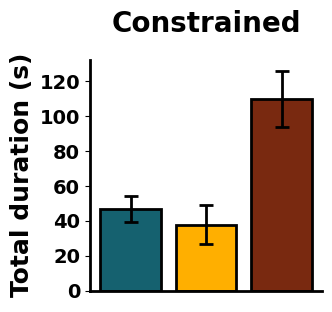

In [50]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar\n(exposure 2)': (1.0, 0.6862745098039216, 0.0),
                'long-term familiar': hex_2_rgb('#792910')
                }
hatches = ['','','']  
plt.figure(figsize= (3,3))           
plt.bar(color_id_dict.keys(), avg_events, yerr = sem_events,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
plt.ylabel('Total duration (s)', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
plt.savefig('phase3_behavior.png', format='png', dpi=600, transparent = True, bbox_inches='tight')

In [13]:
from scipy.stats import ttest_rel
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
event_total_time= event_total_time[['familiar', 'cagemate', 'novel']]
results = {}
p_values = pd.DataFrame(index=event_total_time.columns, columns=event_total_time.columns)
p_value_list = []
for pair in combinations(event_total_time.columns, 2):
    t_stat, p_value = ttest_rel(event_total_time[pair[0]],event_total_time[pair[1]])
    results[pair] = [t_stat, p_value]
    p_value_list.append(p_value)
            
results


{('familiar', 'cagemate'): [-4.218658404598381, 0.003943159233508464],
 ('familiar', 'novel'): [-1.1697445302390637, 0.2803859123509654],
 ('cagemate', 'novel'): [3.2341555193563387, 0.014368822748599342]}

In [14]:
adjusted_p_values = multipletests(p_value_list, method='holm')
adjusted_p_values

(array([ True, False,  True]),
 array([0.01182948, 0.28038591, 0.02873765]),
 0.016952427508441503,
 0.016666666666666666)